# scCODA — simple wrapper

Pass:
- `adata` — AnnData object (cell-level)
- `annotation_col` — obs column with cell-type labels
- `reference_ct` — reference cell type (or `"automatic"`)

and get DA results back.

In [4]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# JAX / GPU setup (comment out if running CPU-only)
os.environ['JAX_PLATFORMS'] = 'cuda'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.9'

import jax
import pertpy as pt
print('Backend:', jax.default_backend())
print('Devices:', jax.devices())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Backend: gpu
Devices: [CudaDevice(id=0)]


## Config

In [5]:
ADATA_PATH        = "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/adatas/Striatum/Striatum_combined_QC_mmc_ct-cured_zoned.h5ad"

ANNOTATION_COL    = "ct_for_deg"          # obs column to use as cell types
REFERENCE_CT      = "eMSN_D1D2"           # reference cell type, or a specific string

SAMPLE_VAR        = "donor_id"
CONTRAST_VAR      = "condition"
CONTRAST_BASELINE = "Control"
CONTRAST_STIM     = "XDP"
COVARIATES        = [CONTRAST_VAR, "sex", SAMPLE_VAR]   # kept in aggregated obs

FORMULA           = f"C({CONTRAST_VAR}, Treatment('{CONTRAST_BASELINE}')) + sex"
NUTS_ITERATIONS   = 5000

SAVE_FOLDER       = "/home/gdallagl/myworkdir/XDP/data/XDP/NucSec/compositional/scCODA_simple"
os.makedirs(SAVE_FOLDER, exist_ok=True)

## Load data

In [6]:
adata = sc.read_h5ad(ADATA_PATH, backed="r")

adata = adata[
    (adata.obs[ANNOTATION_COL].isin(["Matrix", "eMSN_D1D2"]))
].to_memory().copy()

adata

AnnData object with n_obs × n_vars = 30060 × 38601
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'barcode', 'bcl', 'rna_index', 'library', 'library__barcode', 'frac_mito', 'mol_info_nUMI', 'mol_info_nRead', 'frac_intronic', 'donor_id', 'vireo_prob_max', 'vireo_prob_doublet', 'vireo_n_vars', 'vireo_best_singlet', 'vireo_best_doublet', 'vireo_doublet_logLikRatio', 'dropsift_frac_contamination', 'dropsift_training_label_is_cell', 'dropsift_empty_gene_module_score', 'dropsift_is_cell', 'dropsift_is_cell_prob', 'cell_class', 'leiden_0.1', 'leiden_0.2', 'leiden_0.3', 'leiden_0.4', 'leiden_0.5', 'tissue', 'broad_original_cell_type', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'brain_bank', 'cohort', 'condition', 'sex', 'age_of_ons

In [7]:
col_coupling = "mapping_coupling_for_zoning"
col_zones = "zone"

mask = adata.obs[ANNOTATION_COL].isin(["eMSN_D1D2"])
adata.obs[col_zones] = adata.obs[col_zones].astype(str)  # ensure it's string type to avoid issues with mixed types
adata.obs.loc[mask, col_zones] = "eMSN_D1D2"

mask = adata.obs[col_zones] == "nan"
adata.obs.loc[mask, col_zones] = "unassigned"

In [8]:
adata.obs[col_zones].value_counts()

zone
5             6604
2             4374
6             4109
3             3944
eMSN_D1D2     3667
1             3524
4             3018
unassigned     820
Name: count, dtype: int64

## Run scCODA

In [9]:
def run_sccoda(
    adata,
    annotation_col,
    reference_ct,
    sample_var,
    contrast_var,
    contrast_stim,
    covariates,
    formula,
    save_folder,
    nuts_iterations=5000,
    automatic_reference_absence_threshold=0.1,
):
    """
    Run scCODA on an AnnData object.

    Parameters
    ----------
    adata            : AnnData (cell-level, loaded into memory)
    annotation_col   : obs column with cell-type labels
    reference_ct     : reference cell type string, or 'automatic'
    sample_var       : obs column identifying biological replicates
    contrast_var     : obs column with the condition to test
    contrast_stim    : value in contrast_var treated as 'stimulated'
    covariates       : list of obs columns to keep in the aggregated data
    formula          : patsy formula string
    save_folder      : directory for output files
    nuts_iterations  : number of NUTS posterior samples

    Returns
    -------
    results_df : DataFrame with effect sizes and significance per cell type
    """
    os.makedirs(save_folder, exist_ok=True)

    # Drop samples missing any required covariate
    bad_samples = {
        s
        for cov in covariates
        for s in adata.obs.loc[adata.obs[cov].isna(), sample_var].unique()
    }
    if bad_samples:
        print(f"Dropping {len(bad_samples)} samples with missing covariates: {bad_samples}")
        adata = adata[~adata.obs[sample_var].isin(bad_samples)].copy()

    sccoda = pt.tl.Sccoda()

    # Aggregate to sample × cell-type count matrix
    mdata = sccoda.load(
        adata,
        type="cell_level",
        generate_sample_level=True,
        cell_type_identifier=annotation_col,
        sample_identifier=sample_var,
        covariate_obs=covariates,
        modality_key_1="coda",
    )
    print(mdata)

    # Proportions plot
    proportions_fig = sccoda.plot_boxplots(
        mdata, feature_name=contrast_var, add_dots=True, figsize=(20, 5), return_fig=True
    )
    plt.show()

    # Prepare model (sets reference, builds design matrix)
    mdata = sccoda.prepare(
        mdata,
        formula=formula,
        reference_cell_type=reference_ct,
        automatic_reference_absence_threshold=automatic_reference_absence_threshold,
    )
    print(f"Reference cell type: {mdata['coda'].uns['scCODA_params']['reference_cell_type']}")

    # NUTS sampling
    sccoda.run_nuts(mdata, num_warmup=500, num_samples=nuts_iterations, rng_key=42)

    # Credible effects (sets FDR threshold in-place, must run before get_effect_df)
    credible = (
        pd.DataFrame(sccoda.credible_effects(mdata, est_fdr=0.05))
        .rename(columns={"Final Parameter": "is_significant"})
        .reset_index()
    )
    credible["Covariate"] = credible["Covariate"].str.extract(r'\[T\.(.*?)\]')[0]

    effect_df = sccoda.get_effect_df(mdata).reset_index()
    effect_df["Covariate"] = effect_df["Covariate"].str.extract(r'T\.(.*)$')[0]

    results_df = effect_df.merge(credible, how="left", validate="one_to_one")

    # Barplot (only when there are nonzero effects for the contrast)
    nonzero = results_df[
        (results_df["Covariate"] == contrast_stim) & (results_df["log2-fold change"] != 0)
    ]
    if not nonzero.empty:
        barplot_fig = sccoda.plot_effects_barplot(
            mdata,
            covariates=[contrast_var],
            figsize=(5, max(4, len(results_df) * 0.35)),
            parameter="log2-fold change",
            return_fig=True,
        )
        plt.show()
        #barplot_fig.savefig(f"{save_folder}/logFC_plot.png", bbox_inches="tight", dpi=300)
    else:
        print("All effects shrunk to zero — no barplot generated.")

    # Save
    # proportions_fig.savefig(f"{save_folder}/proportions.png", bbox_inches="tight", dpi=300)
    # results_df.to_csv(f"{save_folder}/results.csv", index=False)

    # Summary table
    sig = results_df[(results_df["Covariate"] == contrast_stim) & results_df["is_significant"]]
    print(f"\nSignificant cell types for '{contrast_stim}':")
    display(sig[["Cell Type", "log2-fold change", "Inclusion probability", "is_significant"]])

    return results_df

MuData object with n_obs × n_vars = 47 × 8
  var:	'n_cells'
  1 modality
    coda:	47 x 8
      obs:	'condition', 'donor_id', 'sex'
      var:	'n_cells'


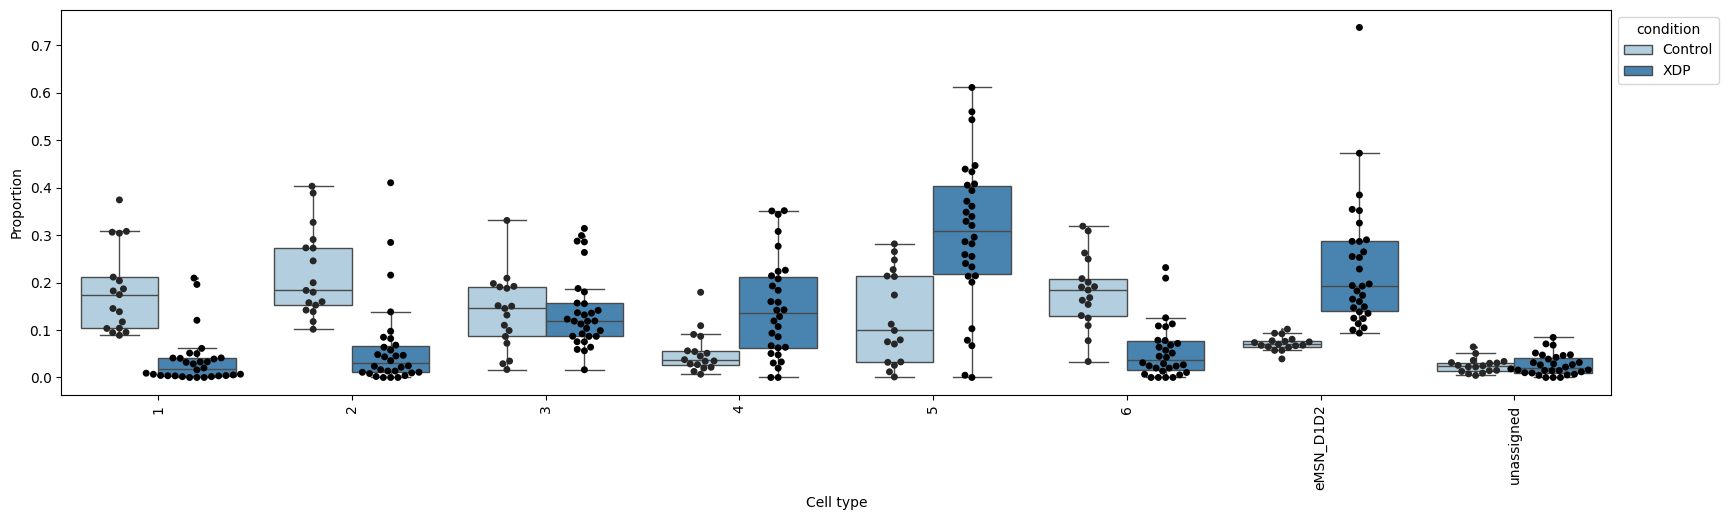

Reference cell type: eMSN_D1D2


sample: 100%|██████████| 2500/2500 [06:52<00:00,  6.06it/s, 255 steps of size 1.27e-02. acc. prob=0.77] 
/home/gdallagl/.pyenv/versions/scoda-gpu/lib/python3.11/site-packages/arviz/__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(
/home/gdallagl/.pyenv/versions/scoda-gpu/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


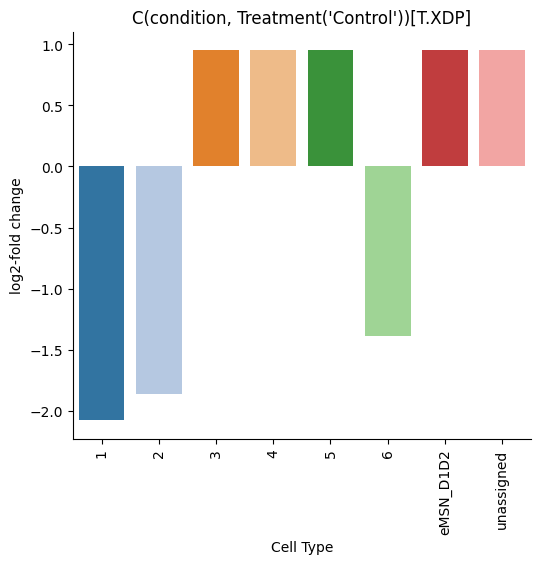


Significant cell types for 'XDP':


,Cell Type,log2-fold change,Inclusion probability,is_significant
0,1,-2.079019,1.0,True
1,2,-1.862098,1.0,True
5,6,-1.386403,1.0,True


,Covariate,Cell Type,Final Parameter,HDI 3%,HDI 97%,SD,Inclusion probability,Expected Sample,log2-fold change,is_significant
0,XDP,1,-2.101345,-2.569,-1.615,0.245,1.0000,26.597484,-2.079019,True
1,XDP,2,-1.950987,-2.361,-1.481,0.235,1.0000,37.719393,-1.862098,True
2,XDP,3,0.000000,-0.841,0.000,0.289,0.7745,147.696826,0.952581,False
3,XDP,4,0.000000,-0.235,0.598,0.139,0.2420,77.568522,0.952581,False
4,XDP,5,0.000000,-0.001,0.872,0.288,0.5445,136.750993,0.952581,False
5,XDP,6,-1.621260,-2.071,-1.141,0.239,1.0000,44.296312,-1.386403,True
6,XDP,eMSN_D1D2,0.000000,0.000,0.000,0.000,0.0000,129.303416,0.952581,False
7,XDP,unassigned,0.000000,-0.832,0.113,0.236,0.3720,39.811734,0.952581,False
8,M,1,0.000000,-0.200,0.376,0.105,0.4120,112.379615,0.000000,False
9,M,2,0.000000,-0.302,0.228,0.088,0.4305,137.123580,0.000000,False


In [12]:
# Load into memory before passing (required by scCODA)
adata_mem = adata.to_memory().copy()

results = run_sccoda(
    adata        = adata_mem,
    annotation_col = col_zones,
    reference_ct = REFERENCE_CT,
    sample_var   = SAMPLE_VAR,
    contrast_var = CONTRAST_VAR,
    contrast_stim = CONTRAST_STIM,
    covariates   = COVARIATES,
    formula      = FORMULA,
    save_folder  = SAVE_FOLDER,
    nuts_iterations = 2000,
)

results